In [12]:
# Basic imports and setup
import os
import yaml
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import SNAC-pack utilities
from utils.tf_global_search5 import run_mlp_search
from utils.tf_visualization import plot_pareto_fronts, plot_3d_pareto_front_heatmap
from utils.tf_local_search1 import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist

# Plotting settings and TF logging
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
print("TensorFlow Version:", tf.__version__)

# --- Configuration ---
N_TRIALS_MLP = 5 # Note: Increase for a real search, 15 is for a quick demo
EPOCHS_MLP = 10
SUBSET_SIZE_MLP = 10000
RESULTS_DIR_MLP = "./results/tutorial1_MLP_Hardware_Aware"

os.makedirs(RESULTS_DIR_MLP, exist_ok=True)

TensorFlow Version: 2.15.0


## The Dataset: MNIST

We'll use the classic MNIST dataset of handwritten digits. First, let's load it and visualize a few examples to see what we're working with.


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 8, 8, 1), x_val shape: (10000, 8, 8, 1)
  y_train shape: (10000,), y_val shape: (10000,)


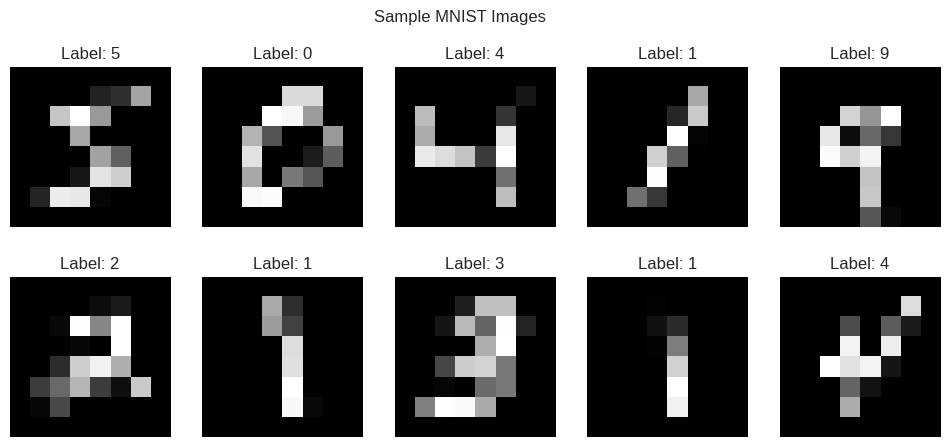

In [13]:

# Load the data for visualization (un-flattened)
x_train_viz, y_train_viz, _, _ = load_and_preprocess_mnist(
    subset_size=SUBSET_SIZE_MLP, 
    flatten=False, 
    one_hot=False
)

# Visualize the first 10 images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_viz[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train_viz[i]}")
    plt.axis('off')
plt.suptitle("Sample MNIST Images")
plt.show()

## Global Search: Finding the Best Architectural Trade-offs

Now, we run the global search. We are not looking for a single "best" model, but the **Pareto optimal front** of models that offer the best balance across four competing objectives:

1.  **Accuracy** (Maximize)
2.  **BOPs** (Minimize)
3.  **FPGA Resources** (Avg. Resource %) (Minimize)
4.  **Latency** (Clock Cycles) (Minimize)

We enable this by setting `use_hardware_metrics=True`, which activates the `rule4ml` integration.


In [14]:

# --- Objectives for Hardware-Aware Search ---
OBJECTIVE_NAMES_HW = ['performance_metric', 'bops', 'avg_resource', 'clock_cycles']
MAXIMIZE_FLAGS_HW = [True, False, False, False] # True = maximize, False = minimize
OBJECTIVE_INFO_HW = list(zip(OBJECTIVE_NAMES_HW, MAXIMIZE_FLAGS_HW))

# --- Define the new, flexible MLP search space ---
# MLP_SEARCH_SPACE = {
#     'num_layers': (2, 5),  # Test MLPs with 2, 3, 4, or 5 layers
#     'hidden_units': [16, 32, 64, 128],
#     'activations': ['ReLU']
# }

# --- Run the MLP Hardware-Aware Search ---
print("\n" + "="*50)
print("Running Part 1: MLP Hardware-Aware Global Search...")
print("This may take a few minutes...")
print("="*50)

study_mlp, searcher_mlp = run_mlp_search(
    results_dir=RESULTS_DIR_MLP,
    n_trials=N_TRIALS_MLP,
    epochs=EPOCHS_MLP,
    subset_size=SUBSET_SIZE_MLP,
    use_hardware_metrics=True # This is the key for hardware co-design!
)

print("\nGlobal Search Complete!")


Running Part 1: MLP Hardware-Aware Global Search...
This may take a few minutes...

Starting MLP Global Search on MNIST



[I 2025-08-30 09:58:45,733] A new study created in memory with name: no-name-ad554756-ce9e-42bf-9c98-16907e42107c


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 64), x_val shape: (10000, 64)
  y_train shape: (10000, 10), y_val shape: (10000, 10)


[I 2025-08-30 09:58:48,813] Trial 0 finished with values: [0.7617999911308289, 2584128.0, 7.03, 72.24] and parameters: {'num_layers': 2, 'hidden_units1': 32, 'activation1': 'sigmoid', 'batchnorm1': False}.


Trial 0: Accuracy=0.7618, BOPs=2584128.0


...

Trial 2: Accuracy=0.8609, BOPs=13750848.0


[I 2025-08-30 09:59:01,095] Trial 3 finished with values: [0.8409000039100647, 10332352.0, 26.269999999999996, 256.86] and parameters: {'num_layers': 2, 'hidden_units1': 128, 'activation1': 'sigmoid', 'batchnorm1': True}.


Trial 3: Accuracy=0.8409, BOPs=10332352.0


[I 2025-08-30 09:59:05,381] Trial 4 finished with values: [0.8648999929428101, 11344640.0, 20.124999999999996, 195.57] and parameters: {'num_layers': 3, 'hidden_units1': 128, 'activation1': 'sigmoid', 'batchnorm1': True, 'hidden_units2': 16, 'activation2': 'tanh', 'batchnorm2': True}.


Trial 4: Accuracy=0.8649, BOPs=11344640.0

CSV results saved to ./results/tutorial1_MLP_Hardware_Aware/mlp_search_results.csv

🏆 Best model architecture (Trial 1) saved for local search:
   - Source: ./results/tutorial1_MLP_Hardware_Aware/trial_1_arch.yaml
   - Destination: ./results/tutorial1_MLP_Hardware_Aware/best_model_for_local_search.yaml
   - Accuracy: 0.8698

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'performance_metric': 0.7617999911308289, 'bops': 2584128.0, 'avg_resource': 7.03, 'clock_cycles': 72.24}
  Params: {'num_layers': 2, 'hidden_units1': 32, 'activation1': 'sigmoid', 'batchnorm1': False}

Rank 2 (Trial 1):
  Values: {'performance_metric': 0.8697999715805054, 'bops': 7052864.0, 'avg_resource': 18.2, 'clock_cycles': 95.25}
  Params: {'num_layers': 3, 'hidden_units1': 64, 'activation1': 'tanh', 'batchnorm1': True, 'hidden_units2': 32, 'activation2': 'tanh', 'batchnorm2': False}

Global Search Complete!


## Analyzing the Global Search Results
The search is complete! The results contain the performance of every architecture tried. Let's visualize the Pareto fronts to understand the trade-offs.



--- Visualizing Hardware-Aware Pareto Fronts ---
2D Pareto fronts plot saved to ./results/tutorial1_MLP_Hardware_Aware/pareto_fronts_2d.png


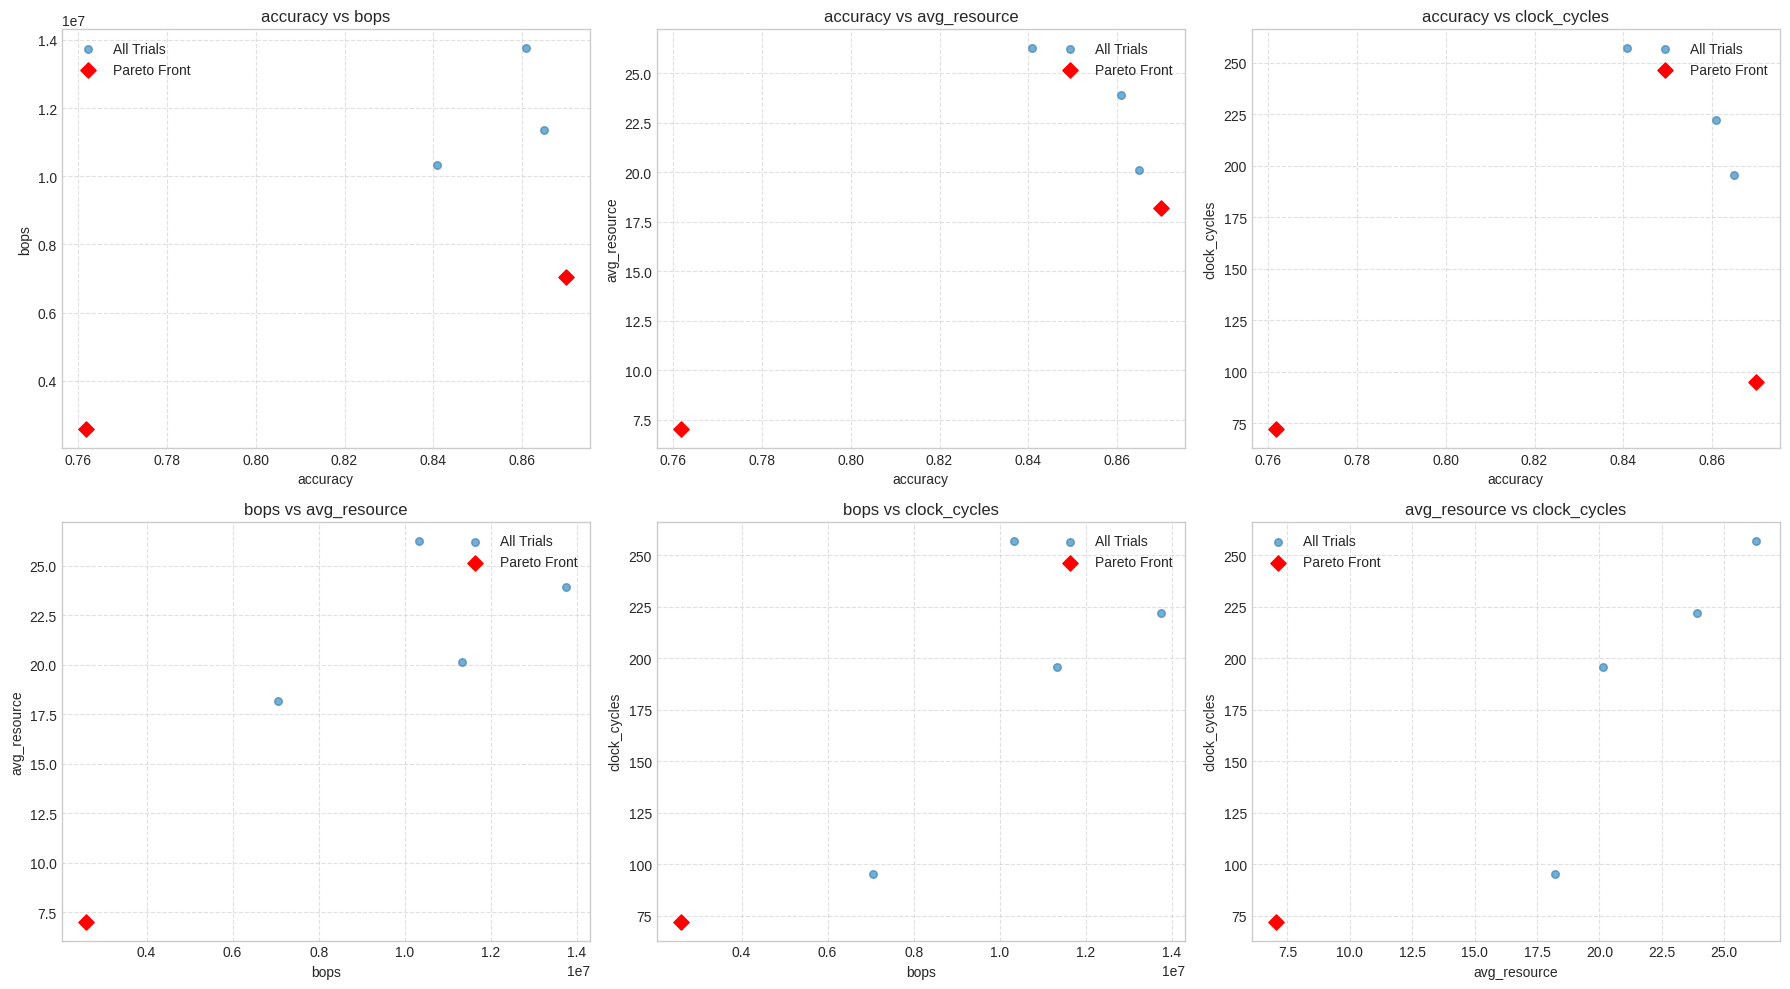


--- Generating 3D Pareto Front Heatmap ---
3D Pareto front plot saved to ./results/tutorial1_MLP_Hardware_Aware/pareto_front_3d.html



MLP search plots saved to: ./results/tutorial1_MLP_Hardware_Aware


In [15]:

results_df_mlp = pd.DataFrame(searcher_mlp.results)

if not results_df_mlp.empty:
    print("\n--- Visualizing Hardware-Aware Pareto Fronts ---")
    # Rename 'performance_metric' to 'accuracy' for clearer plot labels
    results_df_mlp.rename(columns={'performance_metric': 'accuracy'}, inplace=True)
    OBJECTIVE_INFO_HW[0] = ('accuracy', True)
    
    plot_pareto_fronts(results_df_mlp, OBJECTIVE_INFO_HW, save_dir=searcher_mlp.results_dir)
    
    print("\n--- Generating 3D Pareto Front Heatmap ---")
    plot_3d_pareto_front_heatmap(results_df_mlp, OBJECTIVE_INFO_HW, save_dir=searcher_mlp.results_dir)
    
    print(f"\nMLP search plots saved to: {searcher_mlp.results_dir}")
else:
    print("MLP search did not yield any results.")

## Local Search: Compressing the Best Model

The global search automatically saved the configuration of the best-performing model (`best_model_for_local_search.yaml`). Now, we'll take this champion architecture and make it even more efficient through **Quantization-Aware Training (QAT)** and **iterative pruning**.


In [16]:

# --- Configuration for Local Search ---
LOCAL_SEARCH_RESULTS_DIR = os.path.join(RESULTS_DIR_MLP, "local_search")
LOCAL_SEARCH_CONFIG_PATH = os.path.join(RESULTS_DIR_MLP, 'local_search_settings.yaml')

# Define settings for QAT (precisions) and pruning
local_search_settings = {
    'precision_pairs': [
        {'total_bits': 8, 'int_bits': 3},
        {'total_bits': 4, 'int_bits': 1},
    ],
    'pruning_iterations': 5,
    'epochs_per_iteration': 8,
    'pruning_rate': 0.8, # Prune 20% of remaining weights each iteration (1 - 0.8)
}

# Write the settings to a YAML file
with open(LOCAL_SEARCH_CONFIG_PATH, 'w') as f:
    yaml.dump(local_search_settings, f)
print(f"Created local search configuration file: {LOCAL_SEARCH_CONFIG_PATH}")

# Path to the best model found by the global search
ARCHITECTURE_YAML_PATH = os.path.join(RESULTS_DIR_MLP, "best_model_for_local_search.yaml")


# --- Load Dataset for Local Search ---
resize_val = 8 # Explicitly match the global search's default size
x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
    resize_val=resize_val, 
    subset_size=SUBSET_SIZE_MLP, 
    flatten=False,
    one_hot=False
)

# --- Run the Local Search ---
if os.path.exists(ARCHITECTURE_YAML_PATH):
    local_search_df = local_search_entrypoint(
        architecture_yaml_path=ARCHITECTURE_YAML_PATH,
        local_search_config_path=LOCAL_SEARCH_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_SEARCH_RESULTS_DIR
    )
else:
    print(f"ERROR: Could not find the architecture file: {ARCHITECTURE_YAML_PATH}")
    local_search_df = pd.DataFrame()

Created local search configuration file: ./results/tutorial1_MLP_Hardware_Aware/local_search_settings.yaml
Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 8, 8, 1), x_val shape: (10000, 8, 8, 1)
  y_train shape: (10000,), y_val shape: (10000,)

 STARTING LOCAL SEARCH STAGE 
--- Loading model architecture from: ./results/tutorial1_MLP_Hardware_Aware/best_model_for_local_search.yaml ---
--- Model successfully reconstructed ---
Model: "BlockArchitecture"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 8, 8, 1)]         0         
                                                                 
 initial_flatten (Flatten)   (None, 64)                0         
                                                                 
 classifier_head (Sequentia  (None, 10)                6826      
 l)                                                          


--- Pruning Iteration 1/5 | Target Sparsity: 0.2000 ---
Epoch 1/8
79/79 [==============================] - 2s 5ms/step - loss: 1.4679 - accuracy: 0.5619 - val_loss: 1.2589 - val_accuracy: 0.7192
Epoch 2/8
79/79 [==============================] - 0s 2ms/step - loss: 0.8188 - accuracy: 0.7804 - val_loss: 0.8230 - val_accuracy: 0.8006
Epoch 3/8
79/79 [==============================] - 0s 2ms/step - loss: 0.6471 - accuracy: 0.8162 - val_loss: 0.6415 - val_accuracy: 0.8247
Epoch 4/8
79/79 [==============================] - 0s 2ms/step - loss: 0.5698 - accuracy: 0.8366 - val_loss: 0.5639 - val_accuracy: 0.8387
Epoch 5/8
79/79 [==============================] - 0s 2ms/step - loss: 0.5210 - accuracy: 0.8495 - val_loss: 0.5166 - val_accuracy: 0.8487
Epoch 6/8
79/79 [==============================] - 0s 2ms/step - loss: 0.4832 - accuracy: 0.8590 - val_loss: 0.4920 - val_accuracy: 0.8545
Epoch 7/8
79/79 [==============================] - 0s 2ms/step - loss: 0.4579 - accuracy: 0.8670 - val_loss: 

/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning:

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.



Epoch 1/8
79/79 [==============================] - 2s 5ms/step - loss: 1.4681 - accuracy: 0.5600 - val_loss: 1.2546 - val_accuracy: 0.7222
Epoch 2/8
79/79 [==============================] - 0s 2ms/step - loss: 0.8159 - accuracy: 0.7790 - val_loss: 0.8308 - val_accuracy: 0.7944
Epoch 3/8
79/79 [==============================] - 0s 2ms/step - loss: 0.6442 - accuracy: 0.8188 - val_loss: 0.6398 - val_accuracy: 0.8249
Epoch 4/8
79/79 [==============================] - 0s 2ms/step - loss: 0.5651 - accuracy: 0.8383 - val_loss: 0.5623 - val_accuracy: 0.8374
Epoch 5/8
79/79 [==============================] - 0s 2ms/step - loss: 0.5196 - accuracy: 0.8489 - val_loss: 0.5172 - val_accuracy: 0.8481
Epoch 6/8
79/79 [==============================] - 0s 2ms/step - loss: 0.4843 - accuracy: 0.8581 - val_loss: 0.4900 - val_accuracy: 0.8545
Epoch 7/8
79/79 [==============================] - 0s 2ms/step - loss: 0.4594 - accuracy: 0.8664 - val_loss: 0.4707 - val_accuracy: 0.8591
Epoch 8/8
79/79 [==========

## Analyzing the Local Search Results

The local search has finished. Let's plot the results from the pruning log to see how accuracy holds up as we increase sparsity for different quantization levels.


Precision 3>: 5 data points
    Iteration  Sparsity  Accuracy
<8          1    0.2000    0.8633
<8          2    0.3600    0.8631
<8          3    0.4880    0.8666
<8          4    0.5904    0.8646
<8          5    0.6723    0.8632
Precision 1>: 5 data points
    Iteration  Sparsity  Accuracy
<4          1    0.2000    0.8638
<4          2    0.3600    0.8626
<4          3    0.4880    0.8641
<4          4    0.5904    0.8653
<4          5    0.6723    0.8631


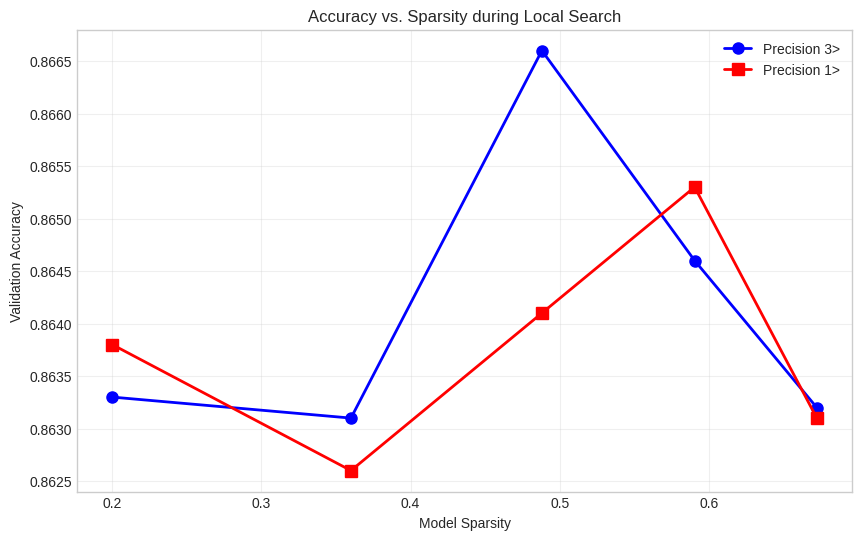

In [19]:
if not local_search_df.empty:
    plt.figure(figsize=(10, 6))
    
    # Define distinct colors and markers
    colors = ['blue', 'red']
    markers = ['o', 's']  # circle and square
    
    precisions = local_search_df['Precision'].unique()
    # print(f"Found precisions: {precisions}")
    # print(f"Data shape: {local_search_df.shape}")
    
    for i, prec in enumerate(precisions):
        subset = local_search_df[local_search_df['Precision'] == prec]
        print(f"Precision {prec}: {len(subset)} data points")
        print(subset[['Iteration', 'Sparsity', 'Accuracy']].to_string())
        
        plt.plot(subset['Sparsity'], subset['Accuracy'], 
                marker=markers[i], linestyle='-', 
                color=colors[i], linewidth=2,
                markersize=8, label=f'Precision {prec}')
    
    plt.title('Accuracy vs. Sparsity during Local Search')
    plt.xlabel('Model Sparsity')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Local search did not produce results to analyze.")
